In [27]:
import navis
import neuron
from fafbseg import flywire
flywire.set_default_dataset("production")
import navis.interfaces.neuron as nrn
import numpy as np
# Load one of the example neurons (a Drosophila projection neuron from the hemibrain connectome)
# Note the conversion to microns!
n = flywire.get_skeletons(720575940623636701).convert_units("um")

df = n.nodes
zero_radius_mask = df['radius'] == 0.0
parent_radii = df.set_index('node_id')['radius']
df.loc[zero_radius_mask, 'radius'] = df.loc[zero_radius_mask, 'parent_id'].map(parent_radii)
n.nodes = df


Default dataset set to "production".


In [28]:
n.nodes 

,node_id,x,y,z,parent_id,radius,type
0,0,615.205566,231.366470,42.179092,65179,0.106,end
1,1,587.931824,255.383453,31.680326,59122,0.186,slab
2,2,587.015686,274.161530,20.780756,58972,0.115,slab
3,3,581.166077,271.133881,11.308748,56446,0.317,end
4,4,576.083008,272.874023,13.438400,54611,0.146,end
...,...,...,...,...,...,...,...
68346,68346,634.538025,259.972687,41.085358,68337,0.165,slab
68347,68347,634.361572,259.784668,39.498123,68345,0.560,slab
68348,68348,634.376465,260.817596,41.976994,68350,0.122,slab
68349,68349,634.981445,260.364258,41.279625,68346,0.254,slab


In [30]:



# Create the compartment model
cmp = nrn.CompartmentModel(n, res=10)

# Set the specific axial resistivity for the entire neuron in Ohm cm
cmp.Ra = 266.1

# Set the specific membran capacitance in mF / cm**2
cmp.cm = 0.8

# Add passive membran properties for the entire neuron
cmp.insert(
    "pas",
    g=1
    / 20800,  # specific leakage conductance = 1/Rm; Rm = specific membran resistance in Ohm cm**2
    e=-60,  # leakage reverse potential
)

n.nodes.head()

,node_id,x,y,z,parent_id,radius,type
0,0,615.205566,231.366470,42.179092,65179,0.106,end
1,1,587.931824,255.383453,31.680326,59122,0.186,slab
2,2,587.015686,274.161530,20.780756,58972,0.115,slab
3,3,581.166077,271.133881,11.308748,56446,0.317,end
4,4,576.083008,272.874023,13.438400,54611,0.146,end


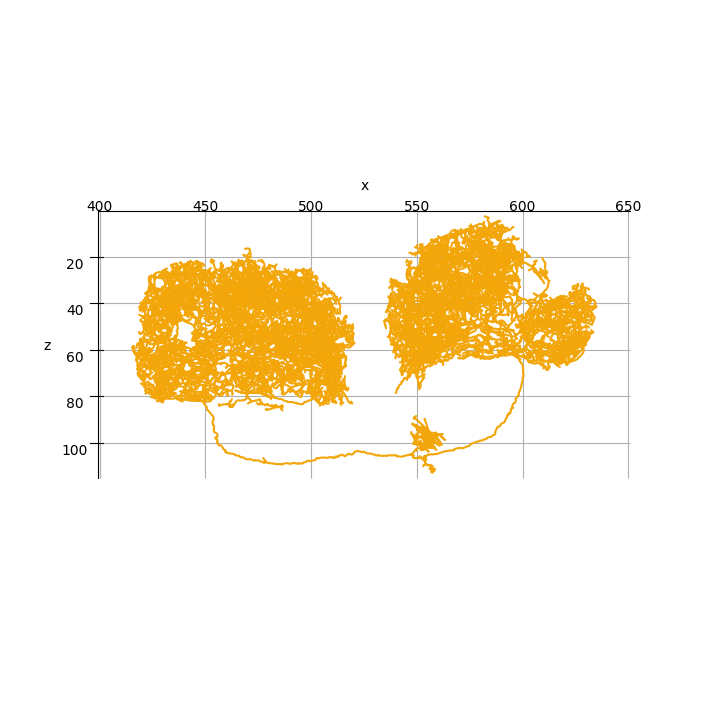

In [32]:
import matplotlib.pyplot as plt

fig, ax = navis.plot2d(
    n, palette="tab10", lw=1.5, method="3d", view=("x", "-z")
)

plt.tight_layout()

In [13]:
n

,
type,navis.TreeNeuron
name,DA1_lPN_R
id,1734350788
n_nodes,4465
n_connectors,2705
n_branches,598
n_leafs,619
cable_length,2131.814941
soma,20
units,1.0 micrometer
